<a href="https://colab.research.google.com/github/dspraneeth07/CognitiveAttackTopology-CAT/blob/main/Notebooks/06_tdi_metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Run: 20260307_054123


/tmp/ipykernel_270/2200857371.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['TDI'] = TDI


Notebook 06 completed


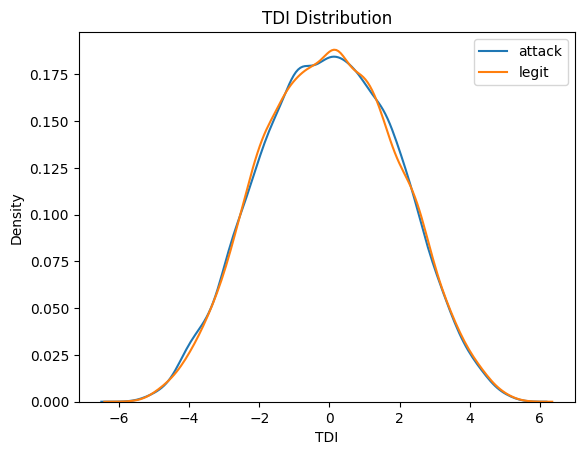

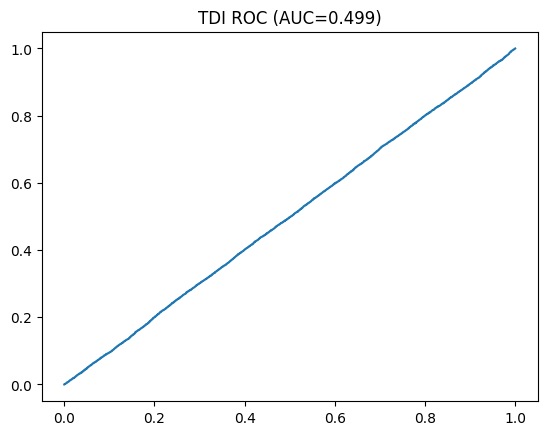

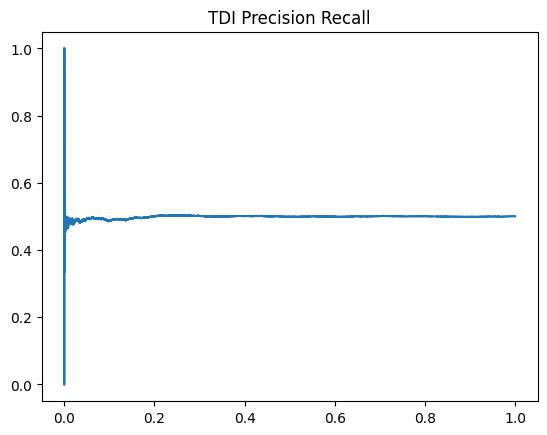

In [2]:
# ===============================================================
# NOTEBOOK 06 — TRUST DISTORTION INDEX (TDI)
# CAT Framework
# ===============================================================

!pip -q install pandas numpy torch scipy scikit-learn seaborn matplotlib pyarrow

import torch
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.metrics import roc_curve, precision_recall_curve, auc

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path('/content/drive/MyDrive/CAT_RESEARCH')

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

RUN_DIR = ROOT/'runs'/RUN_ID
DATA_DIR = ROOT/'data'

REPORT_DIR = RUN_DIR/'reports'
PLOT_DIR = RUN_DIR/'plots'

for p in [RUN_DIR, REPORT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Run:',RUN_ID)

# ===============================================================
# LOAD DATA
# ===============================================================

df = pd.read_parquet(DATA_DIR/'GCT_phase1_100k.parquet')

tensor_path = list(ROOT.glob('runs/*/tensor/trust_tensor.pt'))[-1]

T = torch.load(tensor_path)

users,channels,signals = T.shape

# ===============================================================
# CDE COMPUTATION (tensor-first)
# ===============================================================

weights = torch.ones_like(T)/signals

CDE = torch.einsum('ijk,ijk->i',T,weights).detach().numpy()

# ===============================================================
# TRUST VARIANCE (σ_trust)
# ===============================================================

trust_signals = df[
['urgency_score','fear_trigger_score','authority_claim','trust_manipulation_score']
].values

sigma_trust = trust_signals.std(axis=1)

sigma_trust[sigma_trust==0] = 1e-6

# ===============================================================
# TEMPORAL VARIANCE SMOOTHING (Kalman)
# ===============================================================

class KalmanVariance:

    def __init__(self):
        self.x = 1.0
        self.P = 1.0
        self.Q = 1e-5
        self.R = 1e-2

    def update(self,z):

        K = self.P/(self.P+self.R)

        self.x = self.x + K*(z-self.x)

        self.P = (1-K)*self.P + self.Q

        return self.x

kf = KalmanVariance()

# Calculate sigma_smooth for all interactions first
all_sigma_smooth = np.array([kf.update(v) for v in sigma_trust])

# Add the smoothed variance to the original dataframe
df['sigma_smooth_all'] = all_sigma_smooth

# ===============================================================
# TDI COMPUTATION
# ===============================================================

df_users = df.drop_duplicates('interaction_id').copy()

# Now, extract the sigma_smooth values corresponding to the unique users
sigma_smooth_per_user = df_users['sigma_smooth_all'].values

# Perform the division using the user-aligned arrays
TDI = CDE / sigma_smooth_per_user

df_users['TDI'] = TDI

# ===============================================================
# SPLIT ATTACK VS LEGIT
# ===============================================================

attack = df_users[df_users['human_verified_label']==1]['TDI']
legit = df_users[df_users['human_verified_label']==0]['TDI']

# ===============================================================
# STAT TESTS
# ===============================================================

t_stat,p_t = ttest_ind(attack,legit,equal_var=False)

u_stat,p_u = mannwhitneyu(attack,legit)

cohen_d = (attack.mean()-legit.mean())/np.sqrt(
(attack.std()**2 + legit.std()**2)/2
)

stat_df = pd.DataFrame({

'test':['t_test','mann_whitney','cohen_d'],
'value':[p_t,p_u,cohen_d]

})

stat_df.to_csv(REPORT_DIR/'tdi_statistical_tests.csv',index=False)

# ===============================================================
# DISTRIBUTION PLOTS
# ===============================================================

plt.figure()

sns.kdeplot(attack,label='attack')
sns.kdeplot(legit,label='legit')

plt.legend()

plt.title('TDI Distribution')

plt.savefig(PLOT_DIR/'tdi_distribution.png')

# ===============================================================
# ROC
# ===============================================================

labels = df_users['human_verified_label']

fpr,tpr,thr = roc_curve(labels,df_users['TDI'])

roc_auc = auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr)

plt.title(f'TDI ROC (AUC={roc_auc:.3f})')

plt.savefig(PLOT_DIR/'tdi_roc.png')

# ===============================================================
# PR
# ===============================================================

precision,recall,thr = precision_recall_curve(labels,df_users['TDI'])

plt.figure()

plt.plot(recall,precision)

plt.title('TDI Precision Recall')

plt.savefig(PLOT_DIR/'tdi_pr.png')

# ===============================================================
# THRESHOLD
# ===============================================================

youden = tpr-fpr

best_idx = np.argmax(youden)

threshold = thr[best_idx]

thr_df = pd.DataFrame({

'threshold':[threshold],
'tpr':[tpr[best_idx]],
'fpr':[fpr[best_idx]]

})

thr_df.to_csv(REPORT_DIR/'tdi_threshold_analysis.csv',index=False)

# ===============================================================
# METRICS
# ===============================================================

pred = df_users['TDI'] > threshold

tp = ((pred==1)&(labels==1)).sum()
fp = ((pred==1)&(labels==0)).sum()
fn = ((pred==0)&(labels==1)).sum()

precision_score = tp/(tp+fp+1e-6)
recall_score = tp/(tp+fn+1e-6)
f1 = 2*precision_score*recall_score/(precision_score+recall_score+1e-6)

perf = pd.DataFrame({

'precision':[precision_score],
'recall':[recall_score],
'f1':[f1],
'roc_auc':[roc_auc]

})

perf.to_csv(REPORT_DIR/'tdi_performance_metrics.csv',index=False)

# ===============================================================
# FINAL REPORT
# ===============================================================

report = {

'attack_mean':float(attack.mean()),
'legit_mean':float(legit.mean()),
'cohen_d':float(cohen_d),
'roc_auc':float(roc_auc),
'threshold':float(threshold)

}

with open(REPORT_DIR/'tdi_validation_report.json','w') as f:

    json.dump(report,f,indent=4)

print('Notebook 06 completed')
